## Step 4: Model Building

#### Imports and Load

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_clean = pd.read_csv("../data/loan_clean.csv")
print(df_clean.shape)    

(20000, 39)


#### Split Train and Test Data

In [4]:
X = df_clean.drop(columns="RiskScore")
y = df_clean["RiskScore"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)    

(16000, 38) (4000, 38)


#### Helper Function

In [5]:
results = []

def score(name, y_true, y_pred):
    """Save R², RMSE, MAE for one model and show the row."""
    row = {
        "Model": name,
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }
    results.append(row)
    return pd.DataFrame([row]).round(3)

#### Baseline

In [6]:
# Use the TRAIN average, because in real life you only know the train data
base_pred = np.full(len(y_test), y_train.mean())
score("Baseline (average)", y_test, base_pred)

,Model,R²,RMSE,MAE
0,Baseline (average),-0.002,7.889,6.208


### Model v1 and test metrics

In [7]:
lr_v1 = LinearRegression().fit(X_train, y_train)

print("Train R²:", round(lr_v1.score(X_train, y_train), 3))
score("v1 all 38 features", y_test, lr_v1.predict(X_test))

Train R²: 0.774


,Model,R²,RMSE,MAE
0,v1 all 38 features,0.759,3.871,2.964


#### fit OLS


In [8]:
Xc_train = sm.add_constant(X_train.astype(float))    # add_constant adds the intercept
ols_v1 = sm.OLS(y_train, Xc_train).fit()
print(ols_v1.summary())

                            OLS Regression Results                            
Dep. Variable:              RiskScore   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     1440.
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:18:05   Log-Likelihood:                -43563.
No. Observations:               16000   AIC:                         8.720e+04
Df Residuals:                   15961   BIC:                         8.750e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#### tidy coefficient table

In [9]:
pd.options.display.float_format = "{:.5f}".format

def coef_table(ols):
    """Coefficient, t-value, p-value and 95% interval, sorted by |t|."""
    t = pd.DataFrame({
        "coef": ols.params,
        "t": ols.tvalues,
        "p": ols.pvalues,
        "ci_low": ols.conf_int()[0],
        "ci_high": ols.conf_int()[1],
    }).drop("const")
    return t.loc[t["t"].abs().sort_values(ascending=False).index]

coefs_v1 = coef_table(ols_v1)
coefs_v1.head(10)

,coef,t,p,ci_low,ci_high
AnnualIncome,-0.00009,-118.44981,0.00000,-0.00009,-0.00009
BankruptcyHistory,13.21633,101.44312,0.00000,12.96096,13.47170
DebtToIncomeRatio,15.45676,85.06452,0.00000,15.10060,15.81293
TotalAssets,-0.00002,-79.06733,0.00000,-0.00002,-0.00002
PreviousLoanDefaults,6.90281,70.83041,0.00000,6.71179,7.09384
LengthOfCreditHistory,-0.16722,-47.97565,0.00000,-0.17406,-0.16039
CreditScore,-0.02429,-38.81281,0.00000,-0.02551,-0.02306
LoanAmount,0.00008,35.65246,0.00000,0.00007,0.00008
EmploymentStatus_Unemployed,3.50302,30.48773,0.00000,3.27780,3.72823
EmploymentStatus_Self-Employed,2.88253,26.45667,0.00000,2.66897,3.09609


#### the features that do not matter

In [10]:
coefs_v1[coefs_v1["p"] > 0.05]

,coef,t,p,ci_low,ci_high
JobTenure,-0.02505,-1.92016,0.05485,-0.05063,0.00052
Age,-0.01963,-1.43520,0.15125,-0.04645,0.00718
LoanPurpose_Home,0.09071,1.07710,0.28145,-0.07436,0.25578
MaritalStatus_Married,0.09121,1.03950,0.29859,-0.08078,0.26319
Experience,-0.01285,-0.91365,0.36091,-0.04041,0.01471
NumberOfCreditInquiries,0.02594,0.87919,0.37931,-0.03189,0.08376
NumberOfOpenCreditLines,-0.01329,-0.78967,0.42973,-0.04627,0.01970
NumberOfDependents,-0.01554,-0.73844,0.46026,-0.05678,0.02570
CheckingAccountBalance,0.00001,0.53191,0.59479,-0.00002,0.00003
SavingsAccountBalance,-0.00000,-0.40197,0.68771,-0.00001,0.00001


In [11]:
coefs_v1[coefs_v1["p"] > 0.05].index.tolist()

['JobTenure',
 'Age',
 'LoanPurpose_Home',
 'MaritalStatus_Married',
 'Experience',
 'NumberOfCreditInquiries',
 'NumberOfOpenCreditLines',
 'NumberOfDependents',
 'CheckingAccountBalance',
 'SavingsAccountBalance',
 'UtilityBillsPaymentHistory',
 'HomeOwnershipStatus_Own',
 'LoanPurpose_Education',
 'MaritalStatus_Single']

#### VIF, the overlap check

In [12]:
def vif_table(X):
    """VIF for every feature, highest first."""
    Xc = sm.add_constant(X.astype(float))
    v = pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
        index=Xc.columns,
    )
    return v.drop("const").sort_values(ascending=False)

vif_v1 = vif_table(X_train)
vif_v1.head(8).round(1)

Experience                       29.80000
Age                              29.70000
MaritalStatus_Married             2.30000
MaritalStatus_Single              2.20000
EducationLevel_Bachelor           1.80000
EducationLevel_High School        1.80000
LoanPurpose_Home                  1.70000
LoanPurpose_Debt Consolidation    1.70000
dtype: float64

VIF found only Age and Experience above 10 (about 30 each). All other features are below 2.5.

### Model v2, remove the overlap

#### refit without Experience

In [13]:
X_train_v2 = X_train.drop(columns="Experience")
X_test_v2 = X_test.drop(columns="Experience")

lr_v2 = LinearRegression().fit(X_train_v2, y_train)
score("v2 drop Experience", y_test, lr_v2.predict(X_test_v2))

,Model,R²,RMSE,MAE
0,v2 drop Experience,0.75900,3.87100,2.96400


#### OLS and VIF again

In [14]:
ols_v2 = sm.OLS(y_train, sm.add_constant(X_train_v2.astype(float))).fit()
coefs_v2 = coef_table(ols_v2)

vif_v2 = vif_table(X_train_v2)
vif_v2.head(5).round(1)

MaritalStatus_Married        2.30000
MaritalStatus_Single         2.20000
EducationLevel_Bachelor      1.80000
EducationLevel_High School   1.80000
LoanPurpose_Home             1.70000
dtype: float64

#### before and after for Age

In [15]:
pd.concat(
    [coefs_v1.loc[["Age"], ["coef", "p"]].add_suffix("_v1"),
     coefs_v2.loc[["Age"], ["coef", "p"]].add_suffix("_v2")],
    axis=1,
)

,coef_v1,p_v1,coef_v2,p_v2
Age,-0.01963,0.15125,-0.03189,0.00000


#### Do the log transforms help?

In [16]:
money = ["AnnualIncome", "LoanAmount", "TotalAssets", "TotalLiabilities",
         "SavingsAccountBalance", "CheckingAccountBalance"]

X_train_log = X_train_v2.copy()
X_test_log = X_test_v2.copy()
X_train_log[money] = np.log1p(X_train_log[money])
X_test_log[money] = np.log1p(X_test_log[money])

lr_log = LinearRegression().fit(X_train_log, y_train)
score("v2 + logs", y_test, lr_log.predict(X_test_log))

,Model,R²,RMSE,MAE
0,v2 + logs,0.76300,3.83200,3.15600


Decision: skip the logs. The rule was to skip them if R² rises by less than 0.005.

### Model v3, a simpler model

In [17]:
weak = ols_v2.pvalues.drop("const")
weak = weak[weak > 0.05].index.tolist()
print(len(weak), weak)

X_train_v3 = X_train_v2.drop(columns=weak)
X_test_v3 = X_test_v2.drop(columns=weak)

lr_v3 = LinearRegression().fit(X_train_v3, y_train)
score(f"v3 drop {len(weak)} weak features", y_test, lr_v3.predict(X_test_v3))

12 ['NumberOfDependents', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'SavingsAccountBalance', 'CheckingAccountBalance', 'UtilityBillsPaymentHistory', 'JobTenure', 'MaritalStatus_Married', 'MaritalStatus_Single', 'HomeOwnershipStatus_Own', 'LoanPurpose_Education', 'LoanPurpose_Home']


,Model,R²,RMSE,MAE
0,v3 drop 12 weak features,0.75900,3.87100,2.96400


#### Residual checks

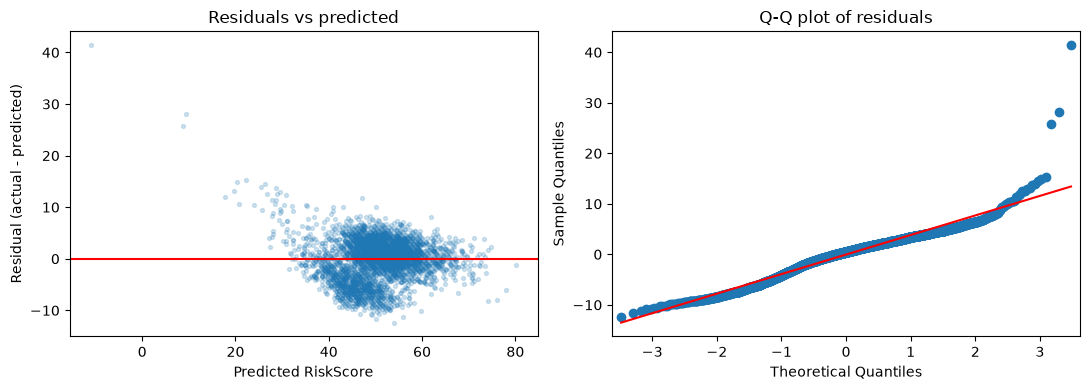

13206   41.40000
15066   28.20000
14994   25.70000
9567    15.30000
2300    14.80000
Name: RiskScore, dtype: float64


In [18]:
pred_v2 = lr_v2.predict(X_test_v2)
resid = y_test - pred_v2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(pred_v2, resid, alpha=0.2, s=8)
axes[0].axhline(0, color="red")
axes[0].set_xlabel("Predicted RiskScore")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted")

sm.qqplot(resid, line="s", ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")

plt.tight_layout()
plt.show()

print(resid.abs().nlargest(5).round(1))    # the 5 biggest misses

### Results table and plain-word coefficients

#### The results table

In [19]:
final = pd.DataFrame(results).drop_duplicates("Model", keep="last").set_index("Model").round(3)
final

,R²,RMSE,MAE
Model,,,
Baseline (average),-0.00200,7.88900,6.20800
v1 all 38 features,0.75900,3.87100,2.96400
v2 drop Experience,0.75900,3.87100,2.96400
v2 + logs,0.76300,3.83200,3.15600
v3 drop 12 weak features,0.75900,3.87100,2.96400


#### top 5 coefficients of v2

In [20]:
coefs_v2.head(5)

,coef,t,p,ci_low,ci_high
AnnualIncome,-0.00009,-118.48201,0.00000,-0.00009,-0.00009
BankruptcyHistory,13.21749,101.45741,0.00000,12.96214,13.47285
DebtToIncomeRatio,15.45734,85.06866,0.00000,15.10118,15.81350
TotalAssets,-0.00002,-79.07107,0.00000,-0.00002,-0.00002
PreviousLoanDefaults,6.90276,70.83021,0.00000,6.71173,7.09378


#### turn income into a readable number

In [21]:
coefs_v2.loc["AnnualIncome", "coef"] * 10_000

np.float64(-0.8814800509944196)